Import the Required Libraries

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import UGate
import random
from math import pi

Create a Random Quantum State to Teleport

In [2]:
# Generate a random unitary gate
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

print("Random gate matrix:")
print(random_gate.to_matrix())

Random gate matrix:
[[-0.97937869+0.j          0.19707408-0.04448802j]
 [-0.02434764-0.20056064j -0.32921993-0.9223865j ]]


Build the Teleportation Circuit

In [3]:
# Create registers
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

# Create the circuit
protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

Apply the Random State to Qubit Q

In [4]:
protocol.append(random_gate, [qubit])

Create the Entangled Pair (Bell State)

In [5]:
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

Alice’s Bell‑State Measurement

In [6]:
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

Bob’s Conditional Operations

In [7]:
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

Verify the Teleported State

In [8]:
protocol.append(random_gate.inverse(), [ebit1])
protocol.measure(ebit1, b)

Display the Full Circuit

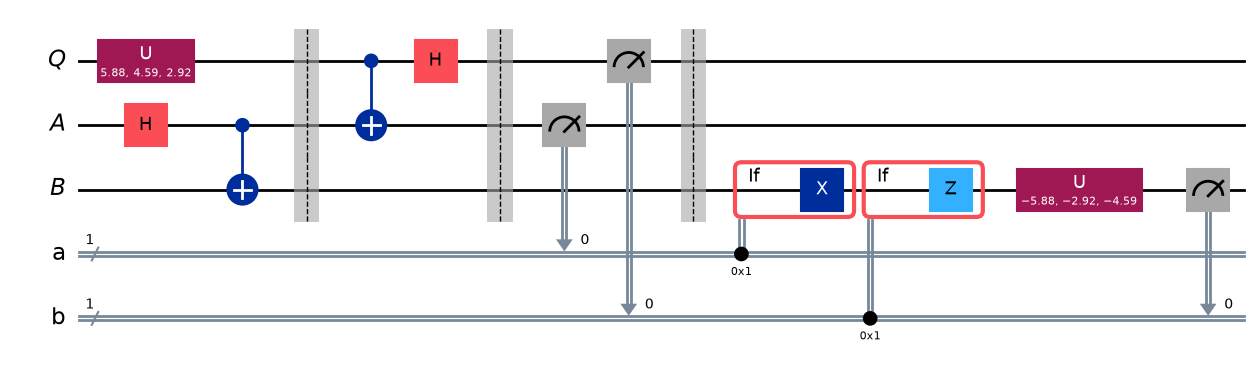

In [9]:
protocol.draw(output="mpl")

Run the Simulation

Measurement results: {'0 1': 514, '0 0': 510}


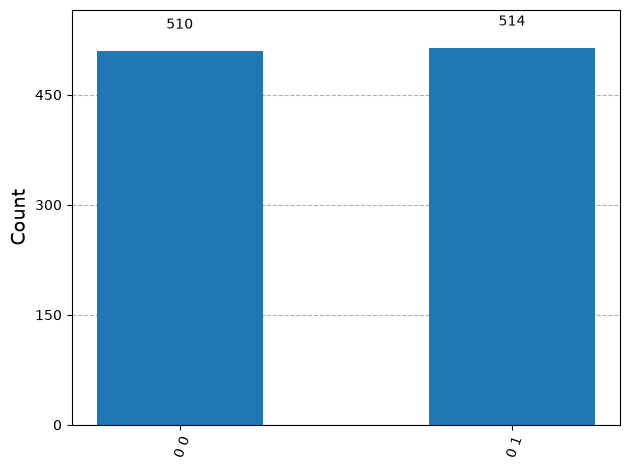

In [10]:
# Create the simulator
simulator = AerSimulator()

# Transpile the circuit for the simulator
compiled_circuit = transpile(protocol, simulator)

# Run the simulation
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(compiled_circuit)

# Display the results
print("Measurement results:", counts)
plot_histogram(counts)

Full Code

Random gate matrix:
[[-0.23525081+0.j          0.96892257+0.07645986j]
 [-0.91049486+0.34008258j -0.22617222+0.06472303j]]
Measurement results: {'0 1': 512, '0 0': 512}


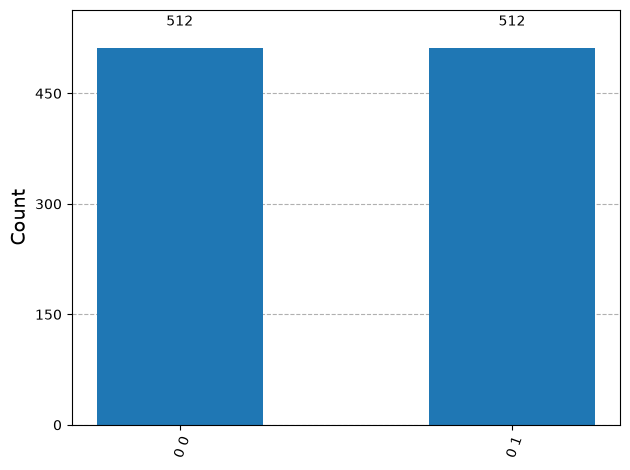

In [11]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import UGate
import random
from math import pi

# 1. Create a random gate
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)
print("Random gate matrix:")
print(random_gate.to_matrix())

# 2. Create registers
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

# 3. Build the circuit
protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Apply random state to Q
protocol.append(random_gate, [qubit])

# Create entangled pair
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's Bell measurement
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob's conditional corrections
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

# Verify teleportation
protocol.append(random_gate.inverse(), [ebit1])
protocol.measure(ebit1, b)

# 4. Display the circuit
protocol.draw(output="mpl")

# 5. Run the simulation
simulator = AerSimulator()
compiled_circuit = transpile(protocol, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(compiled_circuit)

print("Measurement results:", counts)
plot_histogram(counts)